# **Mestría en Inteligencia Artificial Aplicada**

# TC5057.10 Análisis de grandes volumenes de datos

Actividad 3 Aplicar algoritmos de aprendizaje supervisado con PySpark

Alumna: Berenice Chapuli Xochimitl

Matrícula: A01733218



# Introducción

El aprendizaje supervisado es una técnica de Machine Learning donde un modelo aprende a partir de datos etiquetados. Esto quiere decir que el conjunto de datos contiene una variable objetivo conocida, la cual permite que el algoritmo identifique patrones entre las variables de entrada y los resultados esperados. Posteriormente, el modelo puede utilizar estos patrones para realizar predicciones o clasificaciones sobre nuevos datos.

El aprendizaje supervisado permite analizar grandes volúmenes de información para resolver problemas como clasificación, predicción y detección de patrones complejos. Sin embargo, para obtener resultados confiables es necesario realizar un proceso de preparación de datos, selección de variables y evaluación del modelo.

PySpark MLlib proporciona múltiples algoritmos de aprendizaje supervisado que permiten trabajar con grandes volúmenes de datos distribuidos. Entre los algoritmos más representativos disponibles se encuentran:

1. DecisionTreeClassifier
2. RandomForestClassifier
3. GBTClassifier
4. LogisticRegression
5. MultilayerPerceptronClassifier
6. NaiveBayes

En esta actividad se utilizará un algoritmo de clasificación supervisada para analizar información del dataset NBA Play By Play. El objetivo será predecir el tipo de acción realizada durante una jugada utilizando variables numéricas relacionadas con el marcador, periodo, distancia del tiro y tiempo restante.

In [54]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.ml.feature import StringIndexer
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
import pandas as pd
from pyspark.sql.functions import col
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [2]:
spark = SparkSession.builder.appName("NBA_Project").getOrCreate()

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
path_file = '/content/drive/MyDrive/Copia de play_by_play.csv'

nba_df = spark.read.csv(path_file, header=True, inferSchema=True)

In [7]:
nba_df.printSchema()
nba_df.show(5)


root
 |-- game_id: integer (nullable = true)
 |-- game_date: timestamp (nullable = true)
 |-- game_matchup: string (nullable = true)
 |-- team_id: integer (nullable = true)
 |-- person_id: integer (nullable = true)
 |-- action_id: integer (nullable = true)
 |-- action_number: integer (nullable = true)
 |-- clock: string (nullable = true)
 |-- period: integer (nullable = true)
 |-- team_tri_code: string (nullable = true)
 |-- player_name: string (nullable = true)
 |-- player_name_i: string (nullable = true)
 |-- xlegacy: integer (nullable = true)
 |-- ylegacy: integer (nullable = true)
 |-- shot_distance: integer (nullable = true)
 |-- shot_result: string (nullable = true)
 |-- is_field_goal: integer (nullable = true)
 |-- score_home: integer (nullable = true)
 |-- score_away: integer (nullable = true)
 |-- points_total: integer (nullable = true)
 |-- location: string (nullable = true)
 |-- description: string (nullable = true)
 |-- action_type: string (nullable = true)
 |-- subtype: st

In [9]:
df = spark.read.csv("/content/drive/MyDrive/Copia de play_by_play.csv",header=True,inferSchema=True)

In [12]:
df.dtypes

[('game_id', 'int'),
 ('game_date', 'timestamp'),
 ('game_matchup', 'string'),
 ('team_id', 'int'),
 ('person_id', 'int'),
 ('action_id', 'int'),
 ('action_number', 'int'),
 ('clock', 'string'),
 ('period', 'int'),
 ('team_tri_code', 'string'),
 ('player_name', 'string'),
 ('player_name_i', 'string'),
 ('xlegacy', 'int'),
 ('ylegacy', 'int'),
 ('shot_distance', 'int'),
 ('shot_result', 'string'),
 ('is_field_goal', 'int'),
 ('score_home', 'int'),
 ('score_away', 'int'),
 ('points_total', 'int'),
 ('location', 'string'),
 ('description', 'string'),
 ('action_type', 'string'),
 ('subtype', 'string'),
 ('video_available', 'string'),
 ('shot_value', 'string')]

In [20]:
df.groupBy('action_type').count().show()

+--------------------+-------+
|         action_type|  count|
+--------------------+-------+
|  Sharpe (M.Lindsay)|      1|
| Thiero (J.Williams)|      1|
|           Made Shot|2876046|
|    Castle (Z.Zarba)|      1|
|  Williams (J.Goble)|      1|
| Bitadze (1 PF) (...|      1|
| Stewart (6 PF) (...|      1|
|    Morant (M.Davis)|      1|
|      Instant Replay|  40900|
| Gilgeous-Alexand...|      1|
| Spencer (D.Guthrie)|      1|
| K. Williams (Z.Z...|      2|
|  Grant (T.Brothers)|      1|
|   Doncic (S.Wright)|      2|
| J. Williams (J.G...|      2|
|  DiVincenzo (J.Orr)|      1|
| DeRozan (J.Willi...|      2|
| Dosunmu (N.Buchert)|      1|
| Carter Jr. (3 PF...|      1|
|   Shamet (M.Kallio)|      1|
+--------------------+-------+
only showing top 20 rows


In [22]:
print((nba_df.count(), len(nba_df.columns)))

(18246509, 26)


In [23]:
# LIMPIEZA DE DATOS

from pyspark.sql.functions import col, isnan, when, count

In [24]:
# Verificar valores nulos
nba_df.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in nba_df.columns
]).show()

+-------+---------+------------+-------+---------+---------+-------------+-----+------+-------------+-----------+-------------+-------+-------+-------------+-----------+-------------+----------+----------+------------+--------+-----------+-----------+-------+---------------+----------+
|game_id|game_date|game_matchup|team_id|person_id|action_id|action_number|clock|period|team_tri_code|player_name|player_name_i|xlegacy|ylegacy|shot_distance|shot_result|is_field_goal|score_home|score_away|points_total|location|description|action_type|subtype|video_available|shot_value|
+-------+---------+------------+-------+---------+---------+-------------+-----+------+-------------+-----------+-------------+-------+-------+-------------+-----------+-------------+----------+----------+------------+--------+-----------+-----------+-------+---------------+----------+
|      0|        0|           0|      0|        0|        0|            0|    0|     0|      1545143|    1531372|      1531372|      0|    

In [25]:
# Eliminar valores nulos
nba_df = nba_df.dropna()

In [26]:
# Eliminar duplicados
nba_df = nba_df.dropDuplicates()

In [27]:
# Validar limpieza
nba_df.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in nba_df.columns
]).show

<bound method DataFrame.show of DataFrame[game_id: bigint, game_date: bigint, game_matchup: bigint, team_id: bigint, person_id: bigint, action_id: bigint, action_number: bigint, clock: bigint, period: bigint, team_tri_code: bigint, player_name: bigint, player_name_i: bigint, xlegacy: bigint, ylegacy: bigint, shot_distance: bigint, shot_result: bigint, is_field_goal: bigint, score_home: bigint, score_away: bigint, points_total: bigint, location: bigint, description: bigint, action_type: bigint, subtype: bigint, video_available: bigint, shot_value: bigint]>

In [28]:
# CONSTRUCCIÓN DE MUESTRA M
# Se selecciona una muestra reducida para disminuir tiempos de procesamiento.
M = nba_df.sample(withReplacement=False, fraction=0.10, seed=42)
print("Total de registros en muestra M:", M.count())
# Visualizar muestra
M.show(5)

Total de registros en muestra M: 472883
+--------+-------------------+------------+----------+---------+---------+-------------+-----------+------+-------------+-----------+-------------+-------+-------+-------------+-----------+-------------+----------+----------+------------+--------+--------------------+-----------+--------------------+---------------+----------+
| game_id|          game_date|game_matchup|   team_id|person_id|action_id|action_number|      clock|period|team_tri_code|player_name|player_name_i|xlegacy|ylegacy|shot_distance|shot_result|is_field_goal|score_home|score_away|points_total|location|         description|action_type|             subtype|video_available|shot_value|
+--------+-------------------+------------+----------+---------+---------+-------------+-----------+------+-------------+-----------+-------------+-------+-------+-------------+-----------+-------------+----------+----------+------------+--------+--------------------+-----------+--------------------+-

# Preparación del conjunto de entrenamiento y prueba

SELECCIÓN DE VARIABLES

Variable objetivo:  action_type

Variables predictoras seleccionadas: period, shot_distance, score_home, score_away, minutes_remaining y seconds_remaining.

Se seleccionó action_type como variable objetivo porque representa el tipo de acción realizada durante una jugada, lo que permite desarrollar un problema de clasificación supervisada. Las variables predictoras elegidas (period, shot_distance, score_home, score_away, minutes_remaining y seconds_remaining) fueron consideradas relevantes porque describen el contexto del juego, el tiempo restante y las condiciones de la jugada, factores que pueden influir directamente en el tipo de acción ejecutada por los jugadores.

In [32]:
M = M.withColumn(
    "minutes_remaining",
    regexp_extract(col("clock"), "PT(\\d+)M", 1).cast("int")
).withColumn(
    "seconds_remaining",
    regexp_extract(col("clock"), "M(\\d+)\\.", 1).cast("int")
)

model_df = M.select(
    'action_type',
    'period',
    'shot_distance',
    'score_home',
    'score_away',
    'minutes_remaining',
    'seconds_remaining'
)
# Verificar tipos de datos
model_df.printSchema()

root
 |-- action_type: string (nullable = true)
 |-- period: integer (nullable = true)
 |-- shot_distance: integer (nullable = true)
 |-- score_home: integer (nullable = true)
 |-- score_away: integer (nullable = true)
 |-- minutes_remaining: integer (nullable = true)
 |-- seconds_remaining: integer (nullable = true)



Se revisó la distribución de clases para identificar posibles desbalances que pudieran generar sesgos en el modelo.

In [42]:
# DISTRIBUCIÓN DE LA VARIABLE OBJETIVO

model_df.groupBy("action_type").count().show()

+--------------------+------+
|         action_type| count|
+--------------------+------+
|           Made Shot|288171|
|        Jr. 2' Layup|     1|
|Missed Shot      ...|    95|
|         Missed Shot|184518|
| Jr.  Running Dun...|     1|
|Made Shot        ...|    89|
| Jr. 1' Running L...|     1|
| Jr. 26' 3PT Jump...|     1|
| Jr. 3' Running J...|     1|
|    Jr. 4' Jump Shot|     1|
| Jr.  Tip Layup S...|     1|
| Jr. 2' Putback L...|     1|
| Jr. 1' Tip Layup...|     1|
| Jr.  Driving Dun...|     1|
+--------------------+------+



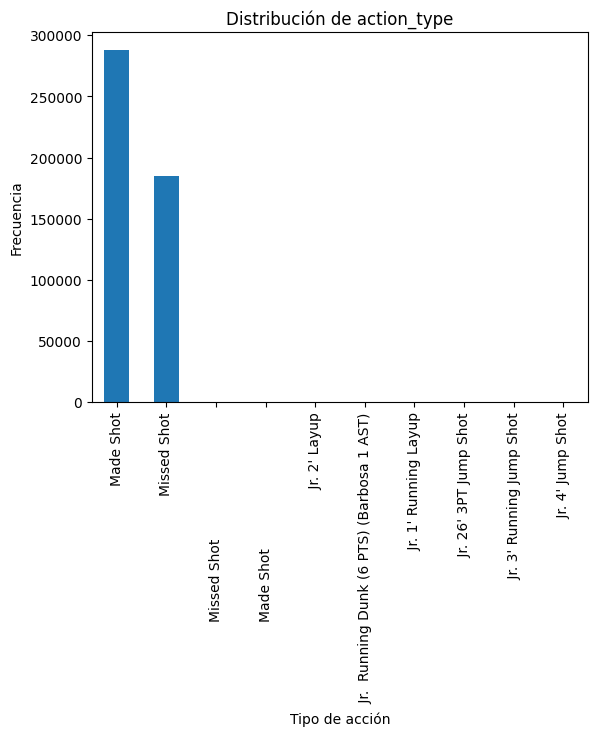

In [46]:

# GRÁFICA DE DISTRIBUCIÓN

pdf = model_df.toPandas()

pdf['action_type'].value_counts().head(10).plot(kind='bar')

plt.title("Distribución de action_type")
plt.xlabel("Tipo de acción")
plt.ylabel("Frecuencia")

plt.show()

La gráfica muestra las categorías más frecuentes de la variable objetivo action_type. Esto permite identificar posibles desbalances entre clases antes del entrenamiento del modelo.

In [33]:
# TRANSFORMAR VARIABLE OBJETIVO

label_indexer = StringIndexer(
    inputCol='action_type',
    outputCol='label'
)

model_df = label_indexer.fit(model_df).transform(model_df)

In [53]:
# CONSTRUCCIÓN DEL VECTOR DE FEATURES
assembler = VectorAssembler(
    inputCols=[
        'period',
        'shot_distance',
        'score_home',
        'score_away',
        'minutes_remaining',
        'seconds_remaining'
    ],
    outputCol='features'
)

final_df = assembler.transform(model_df)


In [35]:
# Dataset final
final_df.select('features', 'label').show(5, truncate=False)

+-----------------------------+-----+
|features                     |label|
+-----------------------------+-----+
|[2.0,3.0,30.0,35.0,10.0,41.0]|0.0  |
|[2.0,2.0,34.0,30.0,10.0,21.0]|0.0  |
|[3.0,0.0,75.0,68.0,2.0,31.0] |0.0  |
|[3.0,1.0,84.0,78.0,0.0,59.0] |0.0  |
|[4.0,5.0,74.0,99.0,11.0,26.0]|0.0  |
+-----------------------------+-----+
only showing top 5 rows


In [36]:
# DIVISIÓN TRAIN / TEST
# Se utiliza una división 80/20.
# 80% entrenamiento
# 20% prueba

train_data, test_data = final_df.randomSplit([0.8, 0.2], seed=42)

print("Entrenamiento:", train_data.count())
print("Prueba:", test_data.count())

# Se utiliza una división 80/20 porque permite entrenar el modelo con suficiente información
# y al mismo tiempo conservar datos independientes para evaluar correctamente el desempeño.

Entrenamiento: 378706
Prueba: 94177


Construcción de modelos de aprendizaje supervisado

RandomForestClassifier fue seleccionado debido a que reduce el sobreajuste mediante el uso de múltiples árboles de decisión y permite manejar relaciones no lineales entre variables.

In [50]:
# RANDOM FOREST CLASSIFIER
rf = RandomForestClassifier(
    labelCol='label',
    featuresCol='features',
    numTrees=20,
    maxDepth=5,
    seed=42
)

In [38]:
# Entrenamiento del modelo

rf_model = rf.fit(train_data)

In [44]:
# Importancia de variables

importance = rf_model.featureImportances

print(importance)

(6,[0,1,2,3,4,5],[0.0007337427232973686,0.00735070473053377,0.5569371329840045,0.4341604847060342,0.0008046164270771407,1.3318429053032294e-05])


In [51]:
# PREDICCIONES

predictions = rf_model.transform(test_data)

# La importancia de variables permite identificar cuáles características tienen mayor influencia en las predicciones realizadas por el modelo.

In [41]:
# Visualizar resultados

predictions.select(
    'action_type',
    'label',
    'prediction',
    'probability'
).show(10, truncate=False)

+-----------+-----+----------+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|action_type|label|prediction|probability                                                                                                                                                                                      |
+-----------+-----+----------+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|Made Shot  |0.0  |0.0       |[0.9528670464934562,0.0468798032585306,0.0,2.452532435331674E-4,0.0,1.5787845209377485E-6,2.1896031411478666E-6,0.0,4.373657317565302E-7,0.0,3.6912510863288584E-6,0.0,0.0,0.0]                  |
|Made Shot  |0.0  |0.0       |[0.924631059222774,0.07504290423183672,0.0,3.181395409092607E-4,0.0,1.

La tabla muestra las predicciones realizadas por el modelo RandomForestClassifier. La columna action_type representa la clase real de la jugada, mientras que prediction indica la clase predicha por el modelo. Las probabilidades reflejan el nivel de confianza de cada predicción, observándose valores superiores al 90% para la clase correcta. Esto indica que el modelo logró clasificar correctamente la mayoría de las jugadas mostradas.

In [49]:
# EVALUACIÓN DEL MODELO
# Accuracy

evaluator_accuracy = MulticlassClassificationEvaluator(
    labelCol='label',
    predictionCol='prediction',
    metricName='accuracy'
)
accuracy = evaluator_accuracy.evaluate(predictions)

print("Accuracy del modelo:", accuracy)
# F1 Score

evaluator_f1 = MulticlassClassificationEvaluator(
    labelCol='label',
    predictionCol='prediction',
    metricName='f1'
)
f1_score = evaluator_f1.evaluate(predictions)

print("F1 Score:", f1_score)

Accuracy del modelo: 0.9996071227582106
F1 Score: 0.9994107234778


El modelo obtuvo un Accuracy de 0.9996 y un F1 Score de 0.9994, lo que indica un desempeño alto en la clasificación de las jugadas. Estos resultados muestran que el algoritmo RandomForestClassifier logró identificar correctamente la mayoría de las clases presentes en el conjunto de prueba.

In [43]:
evaluator_precision = MulticlassClassificationEvaluator(
    labelCol='label',
    predictionCol='prediction',
    metricName='weightedPrecision'
)

precision = evaluator_precision.evaluate(predictions)

print("Precision:", precision)

Precision: 0.9992144028462401


# Interpretación de resultados

El modelo RandomForestClassifier fue entrenado utilizando variables relacionadas con el desarrollo del juego, como el periodo, marcador y distancia del tiro. Para la construcción del modelo se utilizó una división de 80% para entrenamiento y 20% para prueba, lo cual permite evaluar el desempeño del algoritmo sobre datos no vistos previamente.

La variable objetivo seleccionada fue action_type, debido a que representa el tipo de acción realizada durante una jugada y permite desarrollar un problema de clasificación multiclase.

El algoritmo Random Forest fue seleccionado porque reduce el riesgo de sobreajuste al combinar múltiples árboles de decisión. Además, es capaz de trabajar correctamente con grandes volúmenes de datos y relaciones no lineales entre variables.

La métrica Accuracy permite conocer el porcentaje de predicciones correctas realizadas por el modelo, mientras que el F1 Score evalúa el equilibrio entre precisión y recall. Valores altos en ambas métricas indican un mejor desempeño del modelo.

# Conclusiones



En esta actividad se aplicó aprendizaje supervisado utilizando PySpark MLlib sobre un conjunto de datos relacionado con estadísticas de la NBA. Se realizaron las etapas de limpieza de datos, construcción de muestra, preparación del conjunto de entrenamiento y prueba, creación del vector de características y entrenamiento del modelo.

El uso de RandomForestClassifier permitió generar predicciones sobre el tipo de acción realizada durante una jugada. Asimismo, se evaluó el desempeño del modelo mediante métricas de clasificación como Accuracy y F1 Score.

PySpark facilita el procesamiento distribuido y el entrenamiento de modelos de Machine Learning sobre grandes volúmenes de datos, convirtiéndose en una herramienta importante para proyectos de Big Data y analítica avanzada.


# Referencias bibliograficas

Apache Spark. (2024). MLlib: Machine Learning Library. Apache Software Foundation. https://spark.apache.org/mllib/

Karau, H., Konwinski, A., Wendell, P., & Zaharia, M. (2015). Learning Spark: Lightning-fast big data analysis. O’Reilly Media.

Olak, A. (2023). Scaling Machine Learning with Spark: Distributed ML with MLlib, TensorFlow, and PyTorch. O’Reilly Media, Inc.






